# Notes on the top
(From ChatGPT)

Recommended analytic strategy (best practice)

Instead of asking which correlation is correct, do this:

1. Always stratify by diagnosis

Never rely only on pooled correlations.

2. Explicitly test interaction

Use a model like:
```python
Symptom ~ Marker + Diagnosis + Marker × Diagnosis
```

	•	Marker → baseline association
	•	Diagnosis → mean shift
	•	Marker × Diagnosis → effect modification

This formally answers:

“Does disease change how the marker relates to symptoms?”

3. Visualize everything

Scatter plots with:
	•	Color = diagnosis
	•	Separate regression lines
	•	Confidence bands

You will often see the answer before statistics confirm it.



- [ ] Reduce the correlation strength to see how results change.
- [ ] Imbalance the group sizes (e.g., 80% control, 20% disease, etc). 
  - [ ] Can we standardize the group sizes in the correlation analysis?
- [ ] Add one more layer: All disease, but there are subtypes among them. (e.g., All BD, but there are BD I and BD II)
- [ ] Add more disease groups (e.g., Healthy, Disease A, Disease B)
- [ ] Scaling up to many markers & many symptoms.
  - [ ] Multiple testing correction. How to do FDR here? Correcting across all tests? Or per symptom? Or per marker? Or another way?
- [ ] Simpson's paradox?

# What's in this notebook?


# I. Toy example: how the same data gives different correlations

We’ll simulate a dataset with:
	•	Diagnosis: Control vs Disease
	•	One immune marker
	•	One symptom score

We will deliberately construct a case where:
	•	No correlation in controls
	•	Positive correlation in disease
	•	Weak or misleading correlation overall

This mirrors exactly the situations you described.

## Step 1 — Generate synthetic data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n_control = 80
n_disease = 80

# Controls: no real association
marker_control = np.random.normal(5, 1, n_control)
symptom_control = np.random.normal(10, 2, n_control)

# Disease: marker drives symptoms
marker_disease = np.random.normal(8, 1.5, n_disease)
symptom_disease = 5 + 2 * marker_disease + np.random.normal(0, 2, n_disease)

df = pd.DataFrame({
    "marker": np.concatenate([marker_control, marker_disease]),
    "symptom": np.concatenate([symptom_control, symptom_disease]),
    "diagnosis": ["Control"] * n_control + ["Disease"] * n_disease
})

df.head()

,marker,symptom,diagnosis
0,5.496714,9.560656,Control
1,4.861736,10.714225,Control
2,5.647689,12.955788,Control
3,6.523030,8.963460,Control
4,4.765847,8.383013,Control


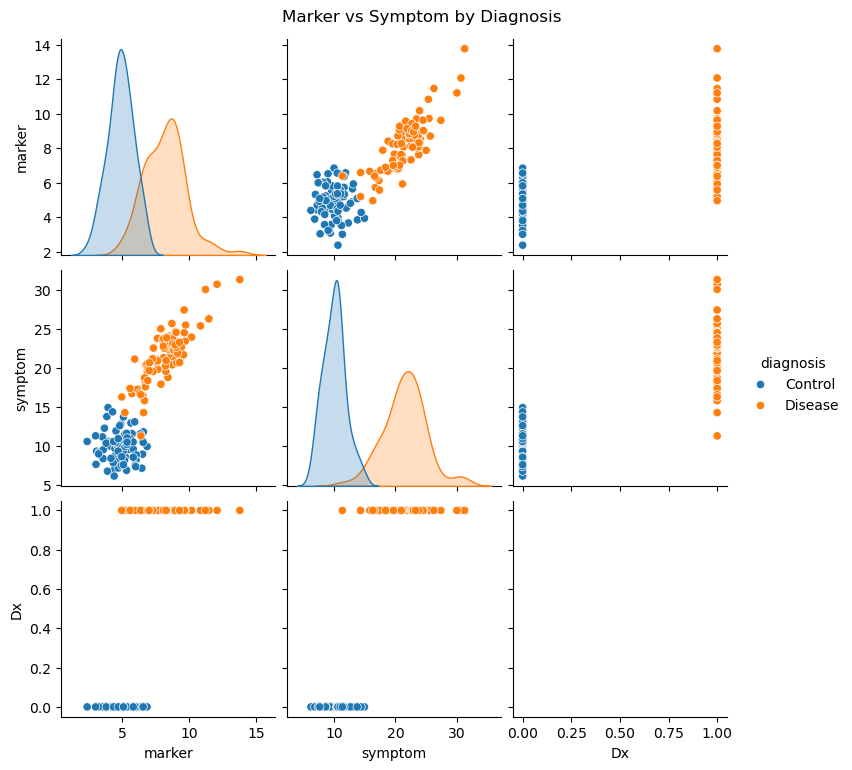

In [ ]:
# Visualize the data

sns.pairplot(data=df, hue="diagnosis") #, corner=True) It is good to visualize both coerner to explore different fitting models. 
plt.suptitle("Marker vs Symptom by Diagnosis", y=1.02)
plt.show()

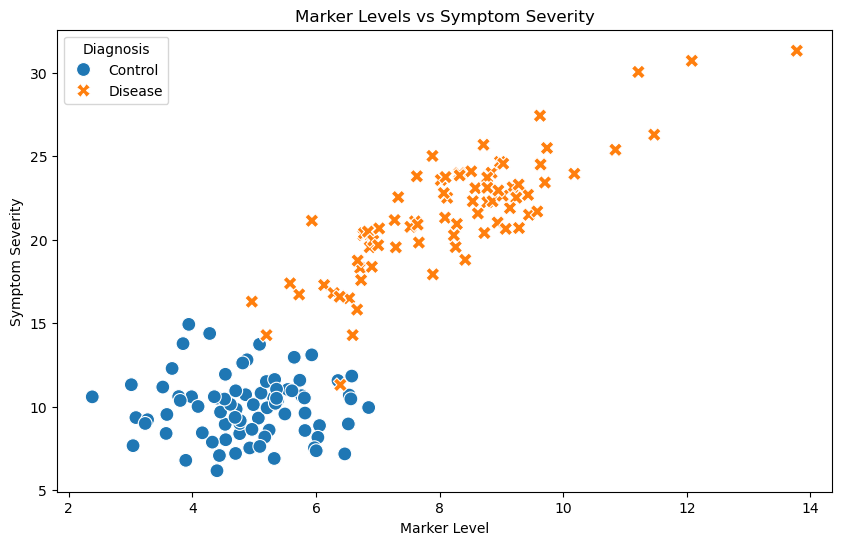

In [2]:
# Visualize the data

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="marker", y="symptom", hue="diagnosis", style="diagnosis", s=100)
plt.title("Marker Levels vs Symptom Severity")
plt.xlabel("Marker Level")
plt.ylabel("Symptom Severity")
plt.legend(title="Diagnosis")

# It looks like there is a correlation overall, but let's quantify it.

## Step 2 — Compute correlations

In [3]:
overall_corr = df["marker"].corr(df["symptom"])
control_corr = df[df.diagnosis == "Control"]["marker"].corr(
    df[df.diagnosis == "Control"]["symptom"]
)
disease_corr = df[df.diagnosis == "Disease"]["marker"].corr(
    df[df.diagnosis == "Disease"]["symptom"]
)

overall_corr, control_corr, disease_corr

(np.float64(0.8797356216601133),
 np.float64(-0.010896153290491565),
 np.float64(0.8361112942505023))

## Step 3 — Visualize (this is crucial)

Text(0.5, 1.0, 'Overall Correlation: 0.88')

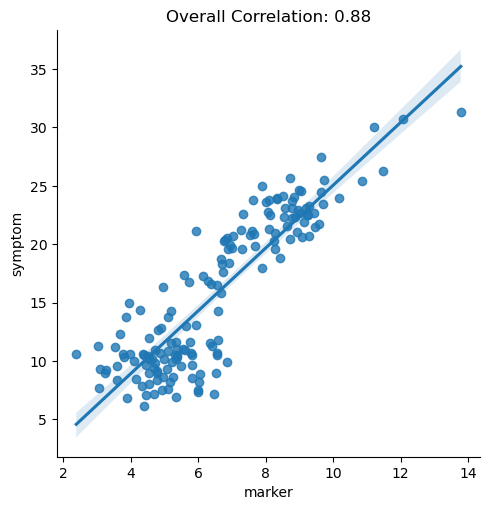

In [6]:
sns.lmplot(data=df, x="marker", y="symptom")
plt.title(f"Overall Correlation: {overall_corr:.2f}")

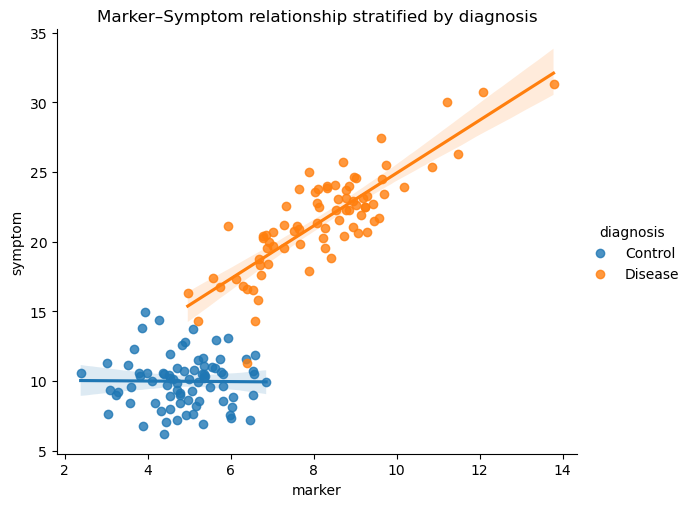

In [4]:
sns.lmplot(
    data=df,
    x="marker",
    y="symptom",
    hue="diagnosis",
    height=5,
    aspect=1.2
)
plt.title("Marker–Symptom relationship stratified by diagnosis")
plt.show()

## What do we see?

- In the overall data, there is a moderate positive correlation between the marker and symptom.
- However, when stratified by diagnosis:
    - Controls show no correlation.
    - Disease group shows a strong positive correlation.
    - This illustrates ==Simpson's paradox==, where the overall trend differs from subgroup trends.

## Step 4 — Interpretation (this is the key learning)

|Group|Correlation means|
|---|---|
|Control|Marker is not symptom-related in normal physiology|
|Disease|Marker tracks symptom severity in pathology|
|Overall|Mixture of diagnosis difference + disease-specific biology|

👉 The overall correlation is not “wrong” — it is just answering the wrong question.

Try other scenarios:
- ✔️ overall, ✖️ control, ✔️ disease → disease-specific association
- ✔️ overall, ✔️ control, ✖️ disease → physiology preserved, pathology disrupts coupling
- ✖️ overall, opposite signs by group → strong effect modification (Simpson’s paradox)

## Conceptual takeaway #1 (very important)

There is no universal “baseline correlation.”
The baseline depends on the scientific question.

	•	Controls = baseline physiology
	•	Disease = baseline pathophysiology
	•	Overall = baseline population separation

In immunology + symptoms, within-group correlations are usually the biologically meaningful ones.

# II. Formal modeling: effect modification & interaction

## 2.1 The key idea (conceptually)

You are no longer asking:

“Is marker correlated with symptom?”

You are asking:

“Is the marker–symptom relationship different between controls and disease?”

This is called:
	•	effect modification
	•	interaction
	•	moderation

All are the same idea in different literatures.

2.2 The correct baseline model

Instead of correlations, use a linear model with interaction:

$$\text{Symptom} = \beta_0 + \beta_1 \cdot \text{Marker} + \beta_2 \cdot \text{Diagnosis} + \beta_3 \cdot (\text{Marker} \times \text{Diagnosis}) + \varepsilon$$

What each term means biologically:
- β0 = baseline symptom level in controls when marker = 0. Intercept.
- β1 = marker–symptom slope in controls (β_control, marker effect in controls)
- β2 = mean symptom difference between disease and control when marker = 0 (β_disease, marker effect in disease)
- β3 = difference in marker–symptom slope between disease and control. How disease changes the marker–symptom relationship (β_interaction, difference: disease minus control)


👉 β₃ is the most important coefficient


2.3 Why correlations alone are insufficient

|Situation|Correlation result|Model result|
|---|---|---|
|Marker matters only in disease|Overall correlation ambiguous|β₃ significant|
|Opposite signs by group|Overall ≈ 0|β₁ and β₃ opposite|
|Disease adds noise|Correlation ↓|β₁ intact, variance ↑|

Correlation cannot disentangle these.
Regression can.

In [ ]:
# TODO: Copy the data generation code here 

## Step 2: Fit the interaction model

In [7]:
import statsmodels.formula.api as smf

# Encode diagnosis as 0/1
df["Dx"] = (df["diagnosis"] == "Disease").astype(int)

model = smf.ols(
    "symptom ~ marker * Dx",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                symptom   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     558.0
Date:                Fri, 02 Jan 2026   Prob (F-statistic):           3.74e-83
Time:                        23:03:34   Log-Likelihood:                -326.90
No. Observations:                 160   AIC:                             661.8
Df Residuals:                     156   BIC:                             674.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.0791      1.104      9.133      0.0

In [ ]:
# We can keep the diagnosis as a categorical variable and fit an interaction model.
import statsmodels.formula.api as smf

model = smf.ols(
    "symptom ~ marker * C(diagnosis)",
    data=df
).fit()

print(model.summary())

# Just be aware of the coefficient order difference.

                            OLS Regression Results                            
Dep. Variable:                symptom   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     558.0
Date:                Sat, 03 Jan 2026   Prob (F-statistic):           3.74e-83
Time:                        00:31:12   Log-Likelihood:                -326.90
No. Observations:                 160   AIC:                             661.8
Df Residuals:                     156   BIC:                             674.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

## Interpretation (line by line)

- Intercept (β₀): 10.0791 → Baseline symptom level in controls
- marker (β₁): -0.0209 → **≈ 0**. In controls, marker is **not related** to symptoms.
- Dx (β₂): -4.1138 -> **< 0**. Disease **reduces** symptom burden overall
- marker:Dx (β₃): 1.9165 → **> 0**. Disease **activates** the marker–symptom relationship

This single model formally proves what correlations only suggested.

In [ ]:

We mainly look at the β₁ (marker effect in controls) and β₃ (interaction term) to evaluate the scenarios.

In these scenarios:
- ✔️ overall, ✖️ control, ✔️ disease → β₁ ≈ 0, β₃ ≠ 0
- ✔️ overall, ✔️ control, ✖️ disease → β₁ ≠ 0, β₃ ≈ −β₁
- ✖️ overall, ✔️ control, ✔️ disease (control and disease in opposite directions) → β₁ and β₃ opposite. Interaction cancels marginal effects



- ✖️ overall, opposite signs by group → strong effect modification (Simpson’s paradox)

## Scaling up to many markers & many symptoms

For your real dataset:
- Repeat this model for each (marker, symptom) pair
- Correct for multiple testing (FDR, not Bonferroni)
- Focus on:
    - Large |β₃| (effect size)
    - Biological coherence across symptoms

This naturally leads to:
- Marker modules
- Symptom domains
- Disease-specific immune axes

## Conceptual takeaway #2 (very important)

A significant interaction means the disease changes biology, not just levels.

This is much stronger evidence than:
	•	Mean differences
	•	Overall correlations